#### AdaBoost Classifier

Adaboost is an emsemble supervised machine learning technique that involves combination of multiple weak learners to form the string classifier/ strong learner.


#### Terminologies:---

(a.)  Weak Learner ------------>      Decision Tree with depth one

(b.)  Strong Learner ---------->      Coombination of multiple weak learners.


#### Step 1: Import all the necessary libraries

In [1298]:
import      numpy               as      np
import      pandas              as      pd
import      matplotlib.pyplot   as      plt
import      seaborn             as      sns

from        sklearn.model_selection   import   train_test_split, GridSearchCV, StratifiedKFold
from        sklearn.preprocessing     import   StandardScaler
from        sklearn.pipeline          import   Pipeline
from        sklearn.ensemble          import   AdaBoostClassifier
from        sklearn.metrics           import   accuracy_score, confusion_matrix, classification_report

#### Step 2: Load the dataset

In [1299]:
df = pd.read_csv("Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


#### OBSERVATIONS:

1.  The above dataset explains whether the particular customer has purchased the product or not based on it's details.

2.  The independent features in the dataset is:----

      (a.)  Gender ------------>   Gender of the customer

      (b.)  Age    ------------>   Age    of the customer

      (c.)  EstimatedSalary ----->  Salary o the customer


3.  The dependent feature in the dataset is

     (a.)  Purchased ------------->  It explains whether the customer has purchased the product or not.

#### Step 3:    Perform the Data Exploration

In [1300]:
#### get the top five rows of the dataset

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [1301]:
#### get the bottom five rows of the dataset

df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [1302]:
#### length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 400


In [1303]:
#### Shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (400, 5)


In [1304]:
#### get the columns used in the dataset

df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [1305]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [1306]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [1307]:
#### get the correlation between all the columns in the dataset

dfa = df[['User ID',	'Age',	'EstimatedSalary',	'Purchased']]

dfa.corr()

,User ID,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.000721,0.071097,0.007120
Age,-0.000721,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,0.155238,1.000000,0.362083
Purchased,0.007120,0.622454,0.362083,1.000000


<Axes: >

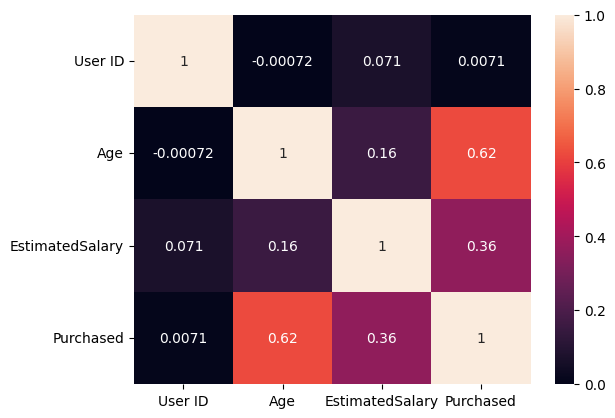

In [1308]:
#### Get the graphical representation between all the numerical columns in the dataset

sns.heatmap(dfa.corr(), annot=True)

#### Step 4:    Perform the Data Cleaning and Feature Engineering

In [1309]:
#### To check for the NULL records in the dataset

df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1310]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,User ID,Gender,Age,EstimatedSalary,Purchased


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [1311]:
#### Remove the unnecessary columns from the dataset

df.drop(columns = ['User ID','Gender'],axis=1,inplace=True)

In [1312]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


#### OBSERVATIONS:

1.  We have the revised dataset that contains the columns 'Age', 'EstimatedSalary' and 'Purchased'.

2.  The inputs in the dataset are 'Age' and the 'EstimatedSalary' and the output is 'Purchased'.

3.  Based on the age and the estimatedsalary of the person, we can now predict whether the customer has purchased the product or not.

In [1313]:
#### Length of the revised dataset 

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 400


In [1314]:
#### Shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (400, 3)


#### Step 5: Divide the dataset into independent and dependent variables

In [1315]:
#### independent features

X = df.drop(columns=['Purchased'],axis=1)

print(X)

     Age  EstimatedSalary
0     19            19000
1     35            20000
2     26            43000
3     27            57000
4     19            76000
..   ...              ...
395   46            41000
396   51            23000
397   50            20000
398   36            33000
399   49            36000

[400 rows x 2 columns]


In [1316]:
#### dependent features

Y = df[['Purchased']]

print(Y)

     Purchased
0            0
1            0
2            0
3            0
4            0
..         ...
395          1
396          1
397          1
398          0
399          1

[400 rows x 1 columns]


#### Step 6: Divide the independent and dependent variables into training and testing data

In [1317]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1318]:
X_train

,Age,EstimatedSalary
65,24,58000
179,31,34000
109,38,80000
379,58,23000
325,41,60000
...,...,...
4,19,76000
18,46,28000
314,39,79000
170,21,88000


In [1319]:
X_test

,Age,EstimatedSalary
331,48,119000
92,26,15000
1,35,20000
234,38,112000
136,20,82000
...,...,...
393,60,42000
151,41,45000
126,42,65000
265,42,108000


In [1320]:
print("Shape of the input training data is:",X_train.shape)
print("Shape of the input testing  data is:",X_test.shape)

Shape of the input training data is: (320, 2)
Shape of the input testing  data is: (80, 2)


In [1321]:
Y_train

,Purchased
65,0
179,0
109,0
379,1
325,0
...,...
4,0
18,1
314,0
170,0


In [1322]:
Y_test

,Purchased
331,1
92,0
1,0
234,0
136,0
...,...
393,1
151,0
126,0
265,1


In [1323]:
print("Shape of the output training data is:",Y_train.shape)
print("Shape of the output testing  data is:",Y_test.shape)

Shape of the output training data is: (320, 1)
Shape of the output testing  data is: (80, 1)


#### Step 7: Perform Feature Scaling on the inputs

In [1324]:
from  sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object of Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

In [1325]:
X_test_scaled = sc.transform(X_test)

In [1326]:
X_train_scaled

array([[-1.23446186, -0.367992  ],
       [-0.57764605, -1.05831408],
       [ 0.07916976,  0.26480323],
       [ 1.95578636, -1.3747117 ],
       [ 0.36066225, -0.31046516],
       [ 0.17300059,  0.17851297],
       [ 2.14344802,  0.35109349],
       [ 0.45449308, -0.48304568],
       [-0.01466107,  0.20727639],
       [-0.01466107,  0.17851297],
       [-0.85913854, -0.33922858],
       [-1.60978518, -1.3747117 ],
       [-1.23446186,  0.52367401],
       [-0.85913854, -0.77067988],
       [ 0.8298164 , -0.85697014],
       [ 1.01747806, -1.20213118],
       [ 0.17300059,  1.01265215],
       [-0.48381522,  1.41534003],
       [-0.29615356,  1.18523267],
       [ 0.17300059,  0.00593246],
       [ 1.11130889, -0.91449698],
       [-0.48381522, -1.5185288 ],
       [-1.79744684, -0.77067988],
       [ 0.07916976,  1.21399609],
       [-0.01466107,  1.90431817],
       [-0.20232273, -1.3747117 ],
       [-1.51595435, -0.0803578 ],
       [-0.20232273,  0.75378137],
       [ 0.92364723,

In [1327]:
X_test_scaled

array([[ 1.01747806,  1.38657661],
       [-1.0468002 , -1.60481906],
       [-0.20232273, -1.46100196],
       [ 0.07916976,  1.18523267],
       [-1.60978518,  0.32233007],
       [ 1.58046304, -0.02283096],
       [ 0.26683142,  0.12098613],
       [ 2.14344802,  0.89759847],
       [ 2.04961719,  0.35109349],
       [-0.1084919 , -1.0870775 ],
       [ 0.26683142, -0.39675542],
       [ 0.92364723,  0.98388873],
       [ 0.92364723, -1.31718486],
       [ 0.73598557,  0.23603981],
       [-0.85913854,  1.50163029],
       [-0.20232273, -0.59809936],
       [-0.57764605,  0.14974955],
       [ 0.8298164 , -1.40347512],
       [ 0.36066225, -0.54057252],
       [ 1.7681247 ,  1.78926449],
       [-0.95296937,  0.55243743],
       [ 0.36066225,  0.46614717],
       [-0.20232273, -0.91449698],
       [ 0.64215474,  1.96184501],
       [-0.67147688,  0.26480323],
       [ 0.36066225,  0.03469588],
       [ 0.26683142,  1.04141557],
       [ 0.73598557, -1.40347512],
       [-1.0468002 ,

#### OBSERVATIONS:

1.  All the inputs have been transformed in the same scale of range between -1 to 1.

#### Step 8: Create the Base Estimator or the Decision Tree Stump

In [1328]:
#### Construct the base model

from  sklearn.tree  import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(
    max_depth        =           1                  ,
    random_state     =          42
)

#### OBSERVATIONS:

1.  Here a base model is created for training the Ada boost classifier.

2.  We have created the decision tree with the depth of 1 level.

#### Step 9: Train the Ada Boost Classifier Model

In [1329]:
from  sklearn.ensemble  import  AdaBoostClassifier


#### create an object for AdaBoostClassifier

ada = AdaBoostClassifier(
    estimator      =           base_estimator            ,
    n_estimators   =               100                   ,
    learning_rate  =               1.0                   ,
    random_state   =               42
)


#### using the object of AdaBoostClassifier, train the model

ada.fit(X_train_scaled, Y_train)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=100, random_state=42)

#### OBSERVATIONS:

1.  Here we have trained the Ada Boost Classifier model with the help of the training data.

2.  The parameters for the model is:-----

     (a.)   estimator    =============>   base_model (Decision Tree with depth of 1 level)

     (b.)   n_estimators =============>   100 weak learners to be considered for training.

     (c.)   learning_rate ============>   1. It controls the speed of convergence.

     (d.)   random_state =============>  It ensures the reproducibility.

#### Step 10: Predict the Ada Boost Classifier model

In [1330]:
Y_pred = ada.predict(X_test_scaled)

In [1331]:
Y_pred

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0])

#### Step 11: Compare the Actual vs Predicted Results

In [1332]:
df_results = pd.DataFrame({
    "Actual Results"    :    Y_test.values.ravel()              ,
    "Predicted Results" :    Y_pred
})

In [1333]:
df_results

,Actual Results,Predicted Results
0,1,1
1,0,0
2,0,0
3,0,1
4,0,0
...,...,...
75,1,1
76,0,0
77,0,0
78,1,1


#### Step 12: Perform the Classification Evaluation Metrics

In [1334]:
from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)



print("===============================Confusion matrix=======================================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", cm)



print("===============================Classification report=======================================================")

cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", cr)

===============================Accuracy score=======================================================
Accuracy score of the model is: 86.25
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[45  6]
 [ 5 24]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.90      0.88      0.89        51
           1       0.80      0.83      0.81        29

    accuracy                           0.86        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.86      0.86      0.86        80



#### OBSERVATIONS:

1.  The accuracy of AdaBoostClassifier Model using Social Networks Ads dataset is 86.25.

2.  The accuracy of the model is high. So it is working fine.

#### Step 13: Predict whether the customer has purchased the product or not based on the sample data

In [1335]:
#### define the sample data

sample = X.iloc[[395]]

print(sample)


#### Transform the sample data

scaled_data = sc.transform(sample)

print(scaled_data)

#### perform the predictions based on the sample data

prediction = ada.predict(scaled_data)

print(prediction)

if(prediction[0] == 1):
    print("Customer has purchased the Social Netwoks Ads (1)")
else:
    print("Customer has not purchased the Social Netwoks Ads (0)")

     Age  EstimatedSalary
395   46            41000
[[ 0.8298164  -0.85697014]]
[1]
Customer has purchased the Social Netwoks Ads (1)


#### Step 14: Perform Hyper Parameter Tuning with GridSearchCV

In [1336]:
#### define the pipeline

from  sklearn.pipeline  import  Pipeline

#### create an object for pipeline

pipeline = Pipeline([
    ("sc"       ,       StandardScaler())           ,
    ("ada"      ,       AdaBoostClassifier(
        DecisionTreeClassifier(
            max_depth       =       1               ,
            random_state    =      42
        )
    ))
])

In [1337]:
#### define the param grid 

param_grid = {
    "ada__n_estimators"   :     [50,100,200]            ,
    "ada__learning_rate"  :     [0.01, 0.1, 1]          ,
    "ada__estimator__max_depth" : [1,2,3]
}

In [1338]:
#### perform the cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [1339]:
#### construct the object for GridSearchCV

grid = GridSearchCV(
    pipeline                                                ,
    param_grid      =       param_grid                      ,
    cv              =         cv                            ,
    scoring         =       'accuracy'                      ,
    n_jobs          =           -1
)

In [1340]:
#### Train the model

grid.fit(X_train, Y_train)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('ada',
                                        AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                                            random_state=42)))]),
             n_jobs=-1,
             param_grid={'ada__estimator__max_depth': [1, 2, 3],
                         'ada__learning_rate': [0.01, 0.1, 1],
                         'ada__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [1341]:
#### Obtain the best parameters and the estimators for the model

best_parameters = grid.best_params_

print("Best Parameters of the model is:", best_parameters)


best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'ada__estimator__max_depth': 2, 'ada__learning_rate': 0.01, 'ada__n_estimators': 100}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('ada',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     random_state=42),
                                    learning_rate=0.01, n_estimators=100))])


In [1342]:
#### Predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [1343]:
Y_pred_grid

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0])

In [1344]:
#### Evaluate the Classification Metrics


from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 90.0
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[46  5]
 [ 3 26]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



#### OBSERVATIONS:

1.  The accuracy of the Ada Boost Classifier using Social Networks Ads dataset has increased from 86.25 to 90. So the model is working fine.

2.  Hence the accuracy of the model has improved using Hyper Parameter Tuning using GridSearchCV

#### Step 15: Predict whether the customer has purchased the product or not based on the sample data using Hyper Parameter Tuning with GridSearchCV

In [1345]:
#### define the sample data

sample = X.iloc[[395]]

print(sample)

#### perform the predictions based on the sample data

prediction = best_estimator.predict(sample)

print(prediction)

if(prediction[0] == 1):
    print("Customer has purchased the Social Netwoks Ads (1)")
else:
    print("Customer has not purchased the Social Netwoks Ads (0)")

     Age  EstimatedSalary
395   46            41000
[1]
Customer has purchased the Social Netwoks Ads (1)
